In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------

df = pd.read_csv("../processed_data/spotify_ml_ready.csv")

print(df.shape)

df.head()

(363142, 28)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock,era_classic,era_early_streaming,era_modern,era_retro
0,0.735,0.478,2,-12.472,1,0.0293,0.1890,0.000002,0.3550,0.947,...,0,0,0,1,0,0,0,0,0,1
1,0.336,0.627,7,-7.463,1,0.0384,0.1640,0.000000,0.0708,0.350,...,0,0,0,1,0,0,0,0,0,1
2,0.598,0.470,8,-8.744,1,0.0496,0.6170,0.000000,0.5050,0.879,...,0,0,0,1,0,0,1,0,0,0
3,0.754,0.424,2,-8.463,1,0.0363,0.6430,0.000000,0.0652,0.806,...,0,0,0,1,0,0,1,0,0,0
4,0.525,0.621,7,-7.364,1,0.1170,0.0489,0.000000,0.2910,0.592,...,0,0,0,1,0,0,0,0,1,0


In [4]:
# ---------------------------------------------------------
# CREATE POPULARITY BINS (IF NOT ALREADY PRESENT)
# ---------------------------------------------------------

low_cut = df["popularity"].quantile(0.40)
high_cut = df["popularity"].quantile(0.90)

def bin_popularity(x):
    if x < low_cut:
        return "low"
    elif x < high_cut:
        return "medium"
    else:
        return "high"

df["popularity_bin"] = df["popularity"].apply(bin_popularity)

print(df["popularity_bin"].value_counts())


popularity_bin
medium    186955
low       138950
high       37237
Name: count, dtype: int64


In [5]:
# ---------------------------------------------------------
# ENCODE TARGET LABELS
# ---------------------------------------------------------

le = LabelEncoder()

df["target"] = le.fit_transform(df["popularity_bin"])

print(le.classes_)

['high' 'low' 'medium']


In [6]:
# ---------------------------------------------------------
# DEFINE FEATURE COLUMNS
# ---------------------------------------------------------

FEATURES = [

    # Audio features
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",

    # Artist popularity
    "avg_artist_popularity"
    
]

In [7]:
# ---------------------------------------------------------
# ADD GENRE + ERA FEATURES
# ---------------------------------------------------------

genre_cols = [c for c in df.columns if c.startswith("genre_")]
era_cols = [c for c in df.columns if c.startswith("era_")]

FEATURES += genre_cols + era_cols

print(FEATURES)

['danceability', 'energy', 'loudness', 'valence', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'key', 'mode', 'duration_ms', 'avg_artist_popularity', 'genre_Blues', 'genre_Classical', 'genre_Country', 'genre_Electronic', 'genre_Folk', 'genre_Hip-Hop', 'genre_Jazz', 'genre_Pop', 'genre_R&B', 'genre_Rock', 'era_classic', 'era_early_streaming', 'era_modern', 'era_retro']


In [8]:
# ---------------------------------------------------------
# CREATE X AND y
# ---------------------------------------------------------

X = df[FEATURES]

y = df["target"]

In [9]:
from sklearn.preprocessing import StandardScaler
import joblib
import os

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

BASE_DIR = os.path.dirname(os.getcwd())  # go from notebooks → project root

scaler_path = os.path.join(BASE_DIR, "models", "scaler.pkl")

joblib.dump(scaler, scaler_path)

['e:\\spotify-popularity-predictor\\models\\scaler.pkl']

In [10]:
# ---------------------------------------------------------
# TRAIN/TEST SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(290513, 27)
(72629, 27)


In [11]:
# ---------------------------------------------------------
# TRAIN RANDOM FOREST
# ---------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

preds = model.predict(X_test)

In [13]:
# ---------------------------------------------------------
# EVALUATION
# ---------------------------------------------------------

print("Accuracy:")
print(accuracy_score(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy:
0.6502223629679604

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.16      0.26      7448
           1       0.70      0.56      0.62     27790
           2       0.63      0.81      0.71     37391

    accuracy                           0.65     72629
   macro avg       0.66      0.51      0.53     72629
weighted avg       0.66      0.65      0.63     72629



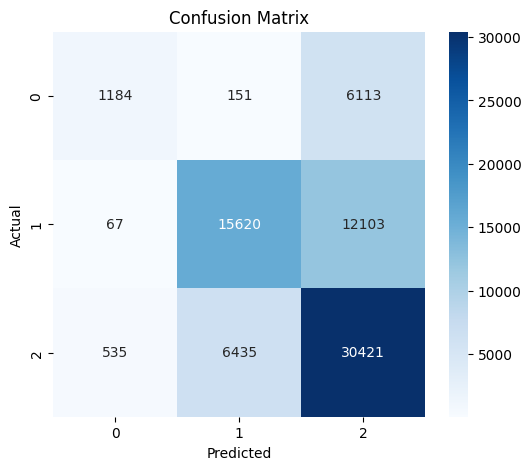

In [14]:
# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
# ---------------------------------------------------------
# FEATURE IMPORTANCE
# ---------------------------------------------------------

importance_df = pd.DataFrame({

    "feature": FEATURES,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(15))

                  feature  importance
12  avg_artist_popularity    0.214347
0            danceability    0.073167
8                liveness    0.071103
11            duration_ms    0.070160
2                loudness    0.069874
6            acousticness    0.068824
1                  energy    0.065437
3                 valence    0.065404
5             speechiness    0.064873
4                   tempo    0.064865
7        instrumentalness    0.055128
9                     key    0.038663
24    era_early_streaming    0.012384
10                   mode    0.009469
18          genre_Hip-Hop    0.008120


In [16]:
import joblib

joblib.dump(model, "spotify_popularity_model.pkl")

print("Model saved.")

Model saved.


In [17]:
import shap

explainer = shap.TreeExplainer(model)

c:\Users\Harjot Dhillon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
